# Similarities between the templates for CUT1 (bdt_all > 0.35)

### Setting up the data and tools

In [1]:
# Importing the notebook with common setup 
%run 'bdt-all-common.ipynb'

Welcome to JupyROOT 6.28/00


Invoke (root_datasets, pandas_datasets) = load_data(inclmc_type="23903000") to load datasets
Invoke (root_datasets, pandas_datasets) = load_data(inclmc_type="23903003") to load dataset for double charm
Invoke  df_signal_23903000 = load_signal_from_inclMC() to load signal from 23903000 Inclusive MC
or
Invoke  df_signal = load_signal_all()
Invoke  df_background = load_background_category(category)


In [2]:
import seaborn as sn
plt.rcParams["figure.figsize"] = (15,4)

## Applying  CUT2 i.e. BDT_all > 0.35

In [4]:
bdt_cutval=0.35

In [24]:
dfcut = df.query(f"bdt_all > {bdt_cutval}")
c = mygroupby(dfcut, 'category')
c['name'] = c.apply(lambda row: categories[f"{row['category']:.4g}"], axis=1)
c

,category,count,Percentage,cumulative %,name
0,19,21750,25.194607,25.194607,Xc_signal_Ypis_displaced_fromB0_fromDp
1,18,10558,12.230099,37.424706,Xc_signal_Ypis_displaced_fromBs_fromDs
2,14,9044,10.476323,47.901029,Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB
3,20,8030,9.301733,57.202762,Xc_signal_Ypis_displaced_fromBp_fromD0
4,0,7367,8.533732,65.736493,Xc_background
5,22,7092,8.215179,73.951673,Xc_signal_Ypis_displaced_fromBs_fromDp
6,24,5483,6.351358,80.303030,Xc_signal_Ypis_displaced_fromBs_fromTau
7,7,4210,4.876749,85.179779,Xc_signal_Ypis_nomatch_doubleCharm
8,23,3531,4.090214,89.269994,Xc_signal_Ypis_displaced_fromBp_fromDp
9,25,1862,2.156890,91.426884,Xc_signal_Ypis_displaced_fromB0_fromD0


There are 17 categories that are bigger than by more than 0.5% of the total

## Using Kolmogorov-Smirnov test to see which distributions are similar

In [25]:
shown_number=17
sq2_2, stauY_2, sbdt_all = similar_categories(dfcut, shown_number)

In [26]:
# Prepare some data to display histogramsand add to display tools
shown_categs = list(c.head(shown_number)['category'])
datasets = { f"{c}":  dfcut.query(f"category == {c}") for c in shown_categs }
datasets["others"] =  dfcut.query(f"category not in {shown_categs}")
datasets_names = { f"{c}": f"{c}:" + categories[f"{c}"] for c in shown_categs}
datasets_names["others"] = "others"

def plot_templates(datasets, datasets_names, myvar):
    htype = 'stepfilled'
    a = 0.30
    plt.hist([ d[myvar] for d in datasets ], bins=40, label=datasets_names, density=True, histtype=htype, alpha=a)
#     if myvar == "tauY_2":
#         plt.xlim([0, 0.004])
    plt.title(myvar)
    plt.legend()

def plot_templates_categs(mycategs, myvar):
    plot_templates([ datasets[d] for d in mycategs ], [ datasets_names[d] for d in mycategs ], myvar)

## Checking q2_2 distributions

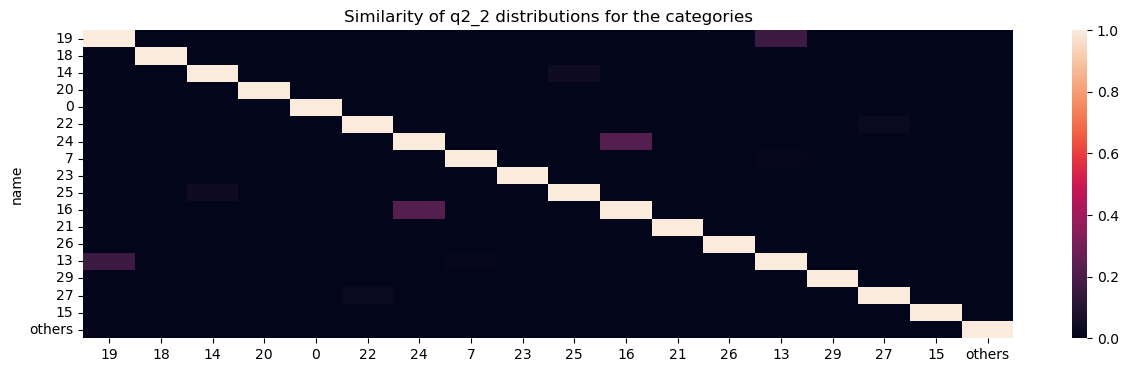

In [27]:
plt.figure()
sn.heatmap(sq2_2)
plt.title("Similarity of q2_2 distributions for the categories");

In [28]:
from pprint import pprint
clusters = find_and_merge_clusters(sq2_2, 0.1)
pprint(clusters)

[['25'],
 ['14'],
 ['27'],
 ['15'],
 ['18'],
 ['26'],
 ['22'],
 ['23'],
 ['13', '19'],
 ['7'],
 ['29'],
 ['others'],
 ['20'],
 ['21'],
 ['24', '16'],
 ['0']]


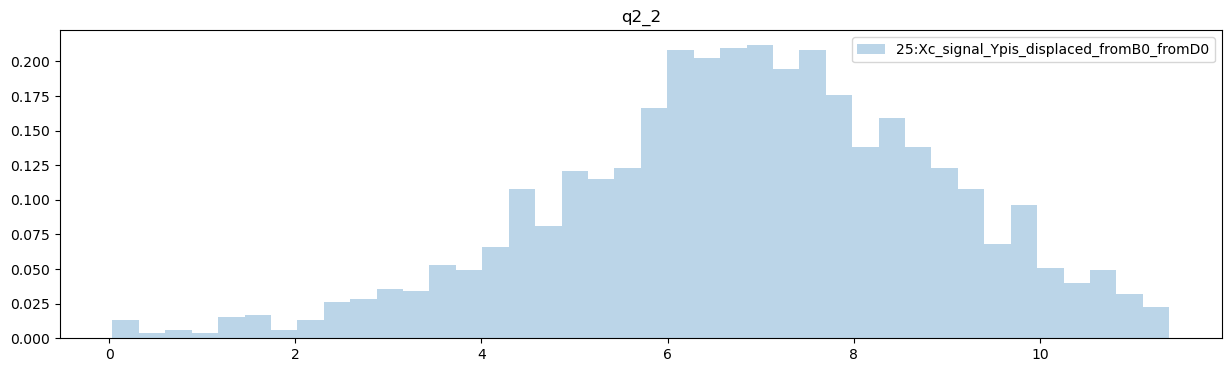

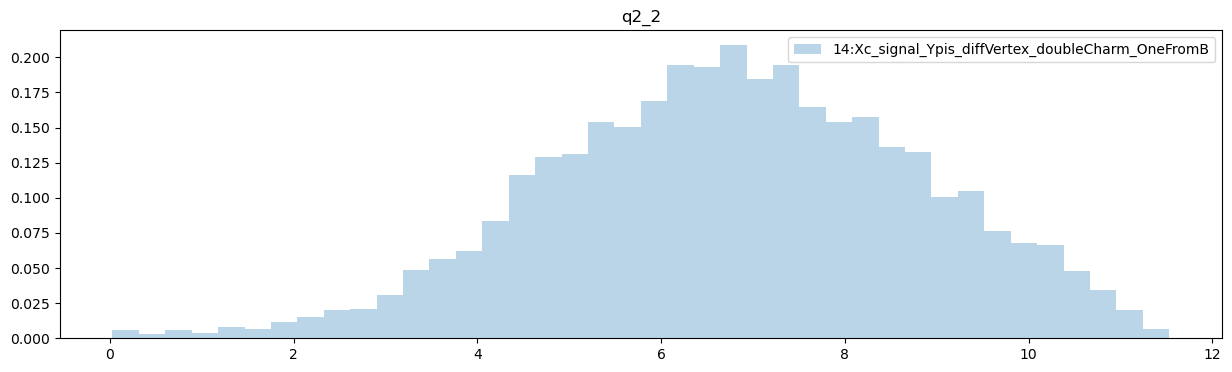

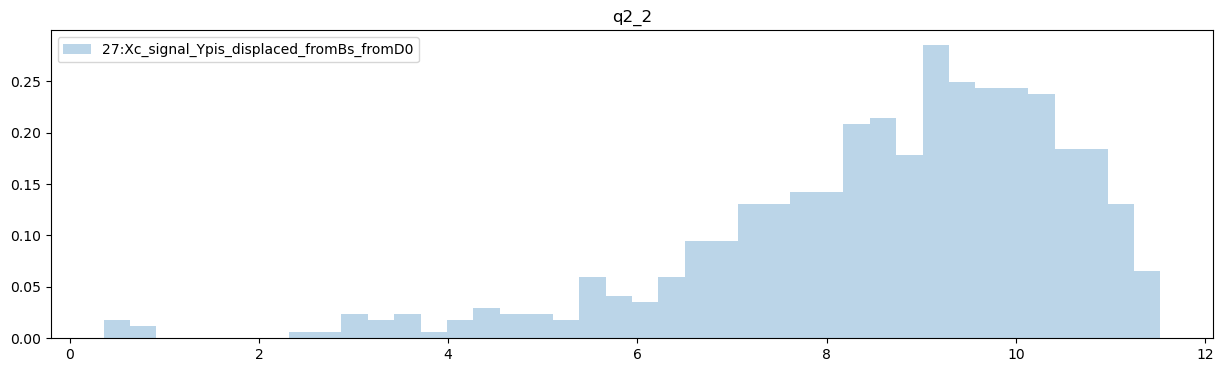

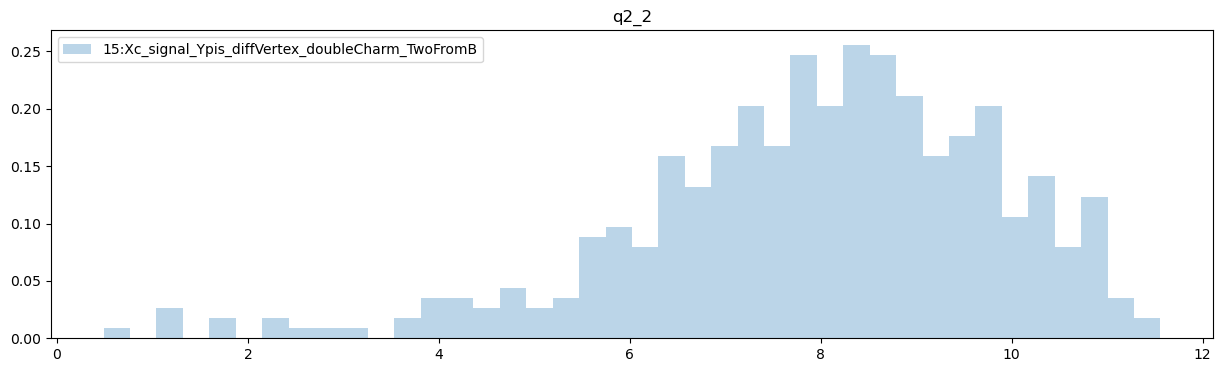

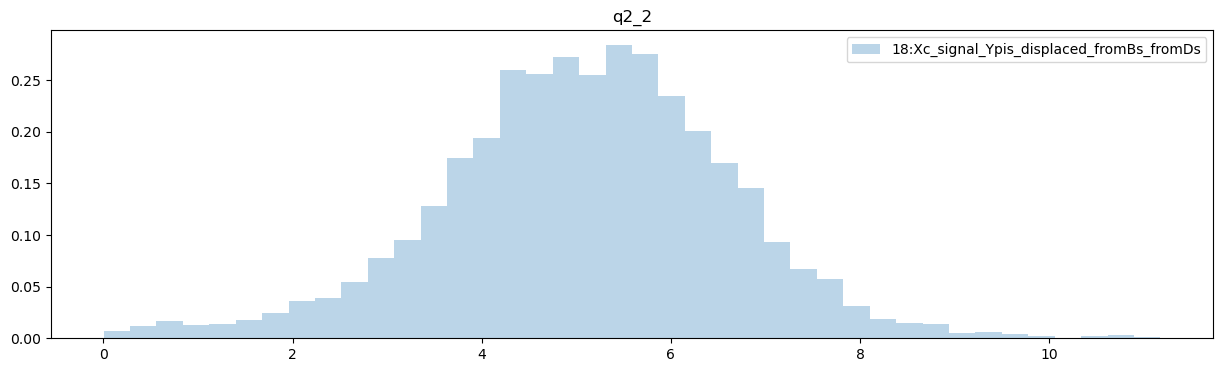

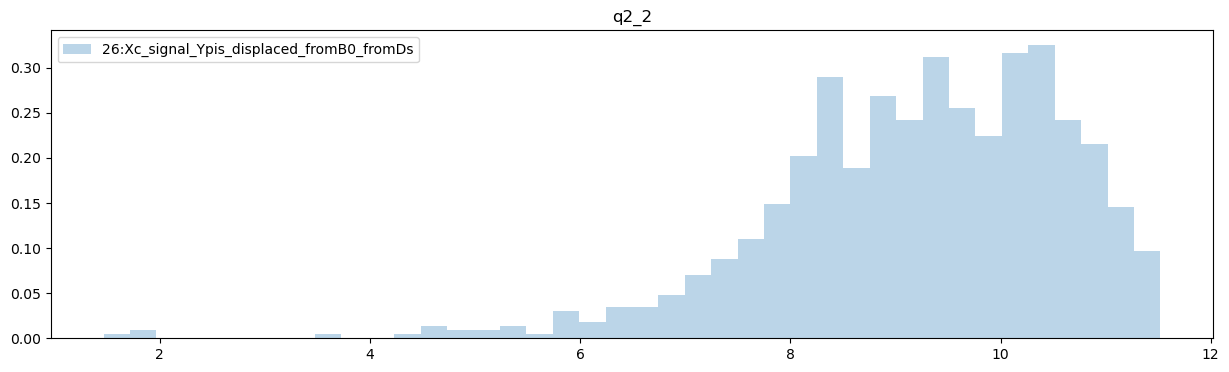

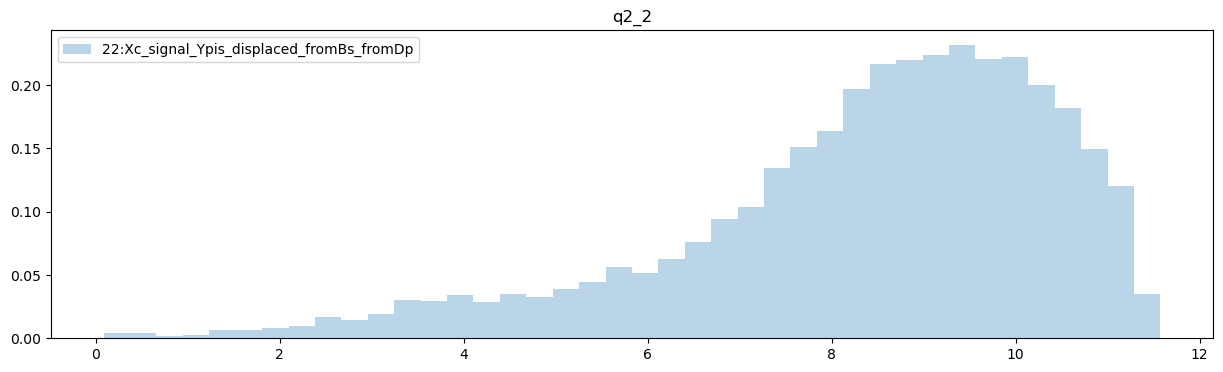

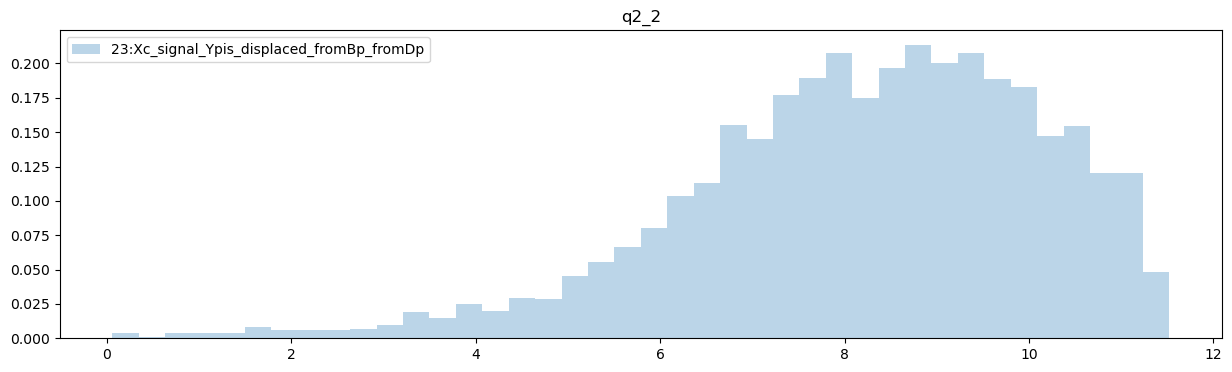

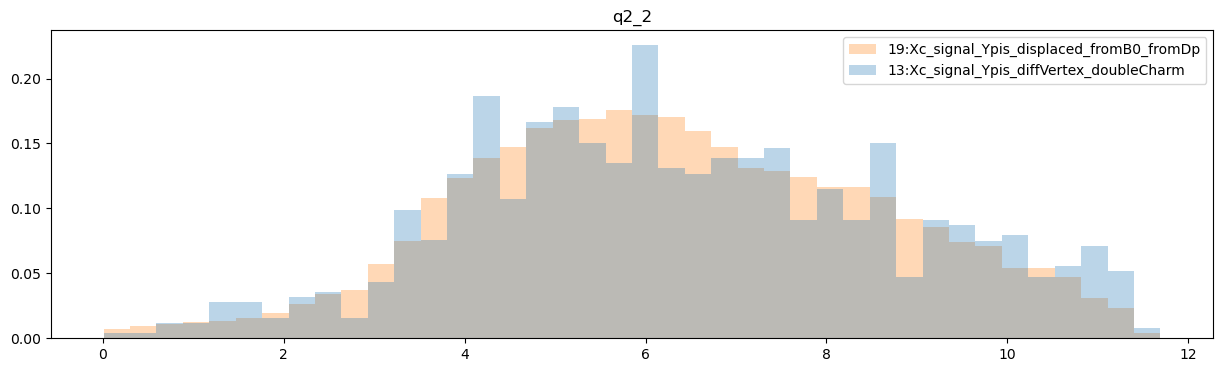

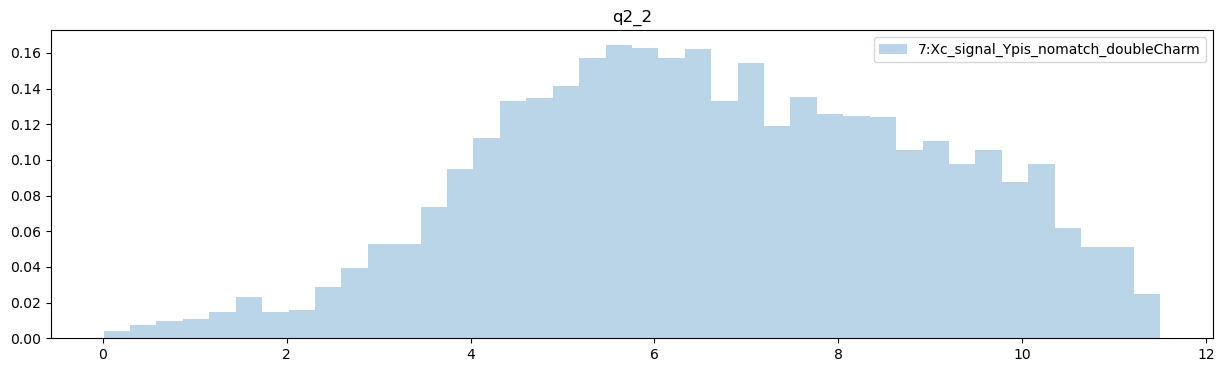

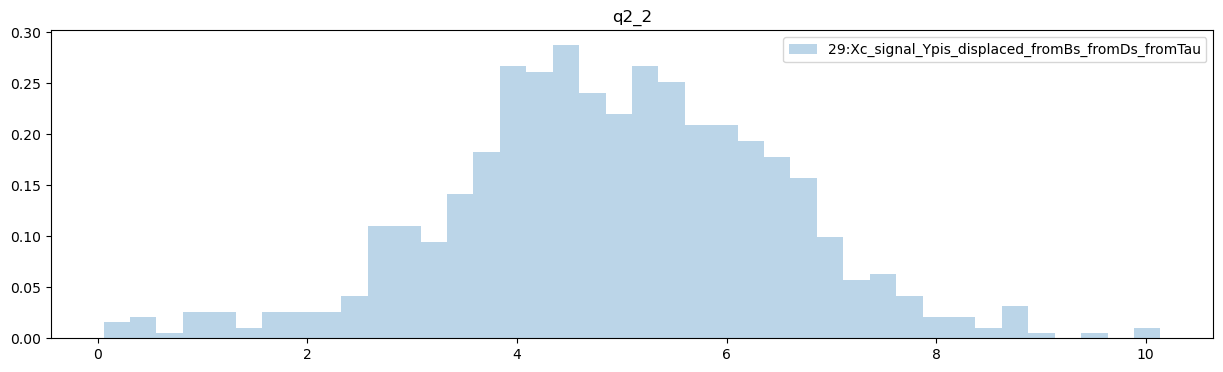

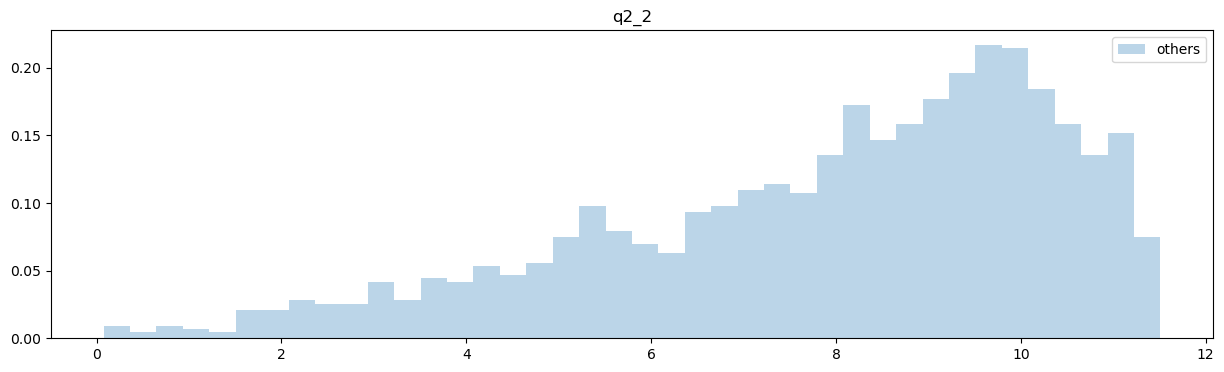

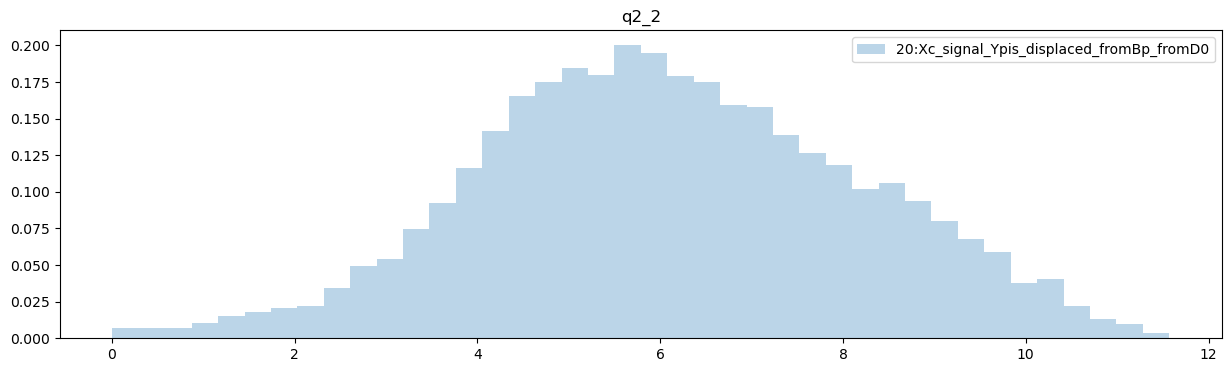

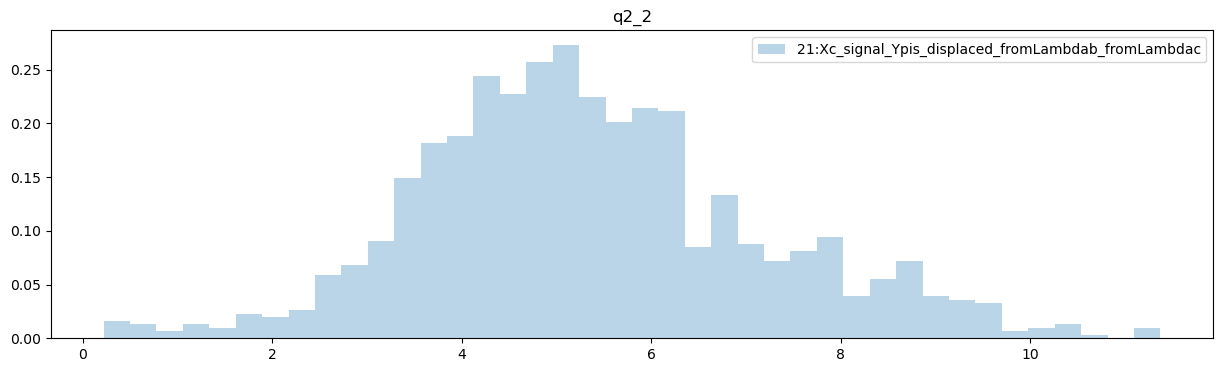

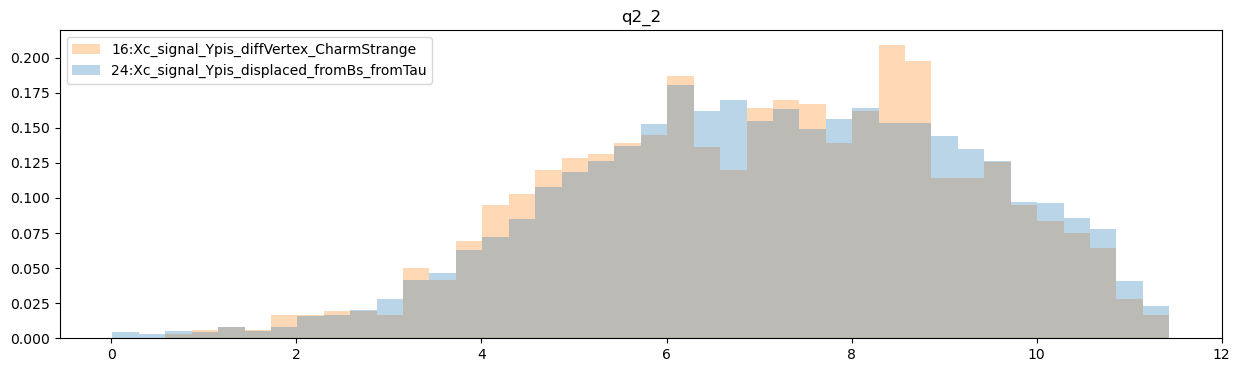

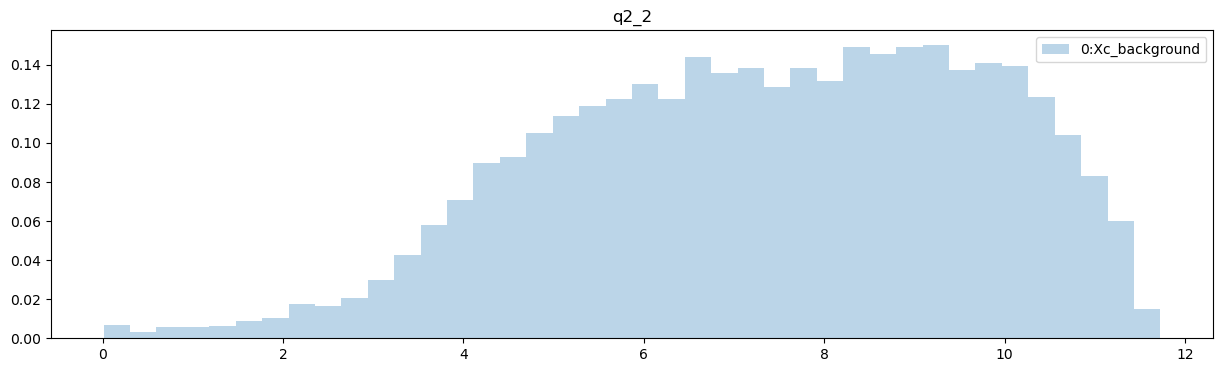

In [29]:
plt.rcParams["figure.figsize"] = (15,4)
for c in clusters:
    plt.figure()
    plot_templates_categs(c, 'q2_2')

## Checking tauY_2 distributions

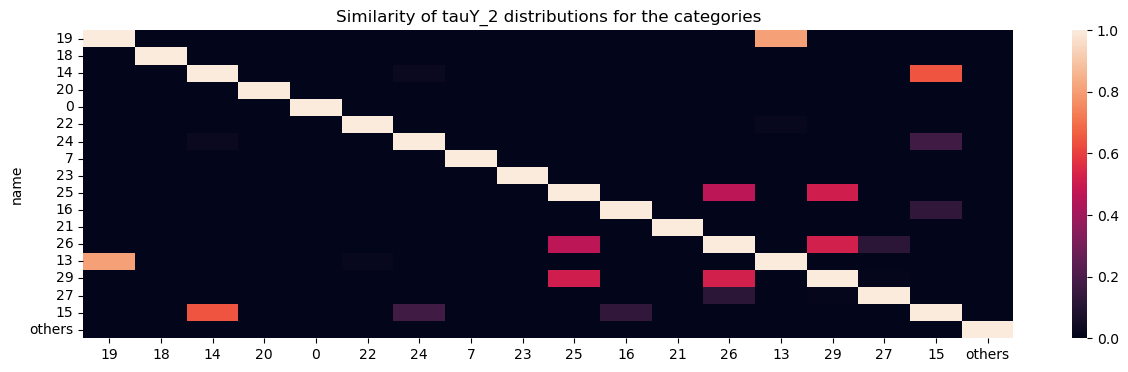

In [30]:
plt.figure()
sn.heatmap(stauY_2)
plt.title("Similarity of tauY_2 distributions for the categories");

In [31]:
from pprint import pprint
clusters = find_and_merge_clusters(stauY_2, 0.1)
pprint(clusters)

[['18'],
 ['22'],
 ['23'],
 ['13', '19'],
 ['7'],
 ['15', '24', '16', '14'],
 ['others'],
 ['20'],
 ['21'],
 ['0'],
 ['29', '25', '26', '27']]


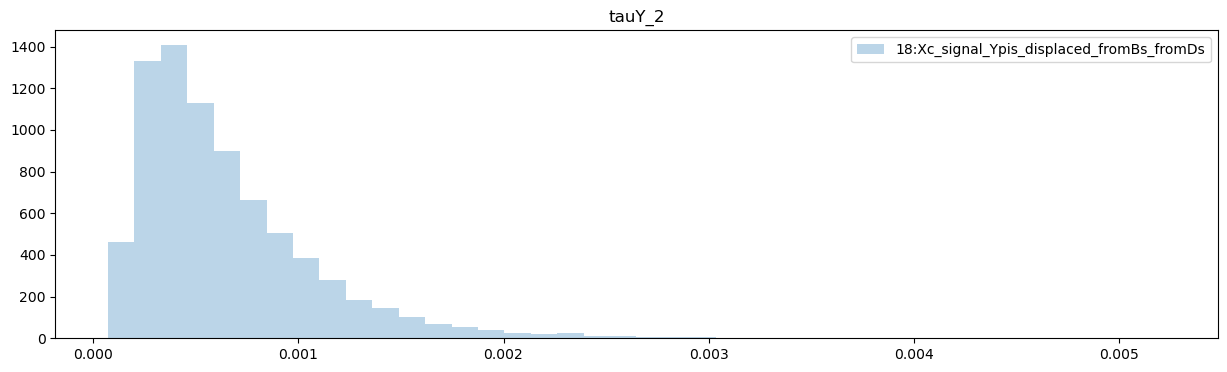

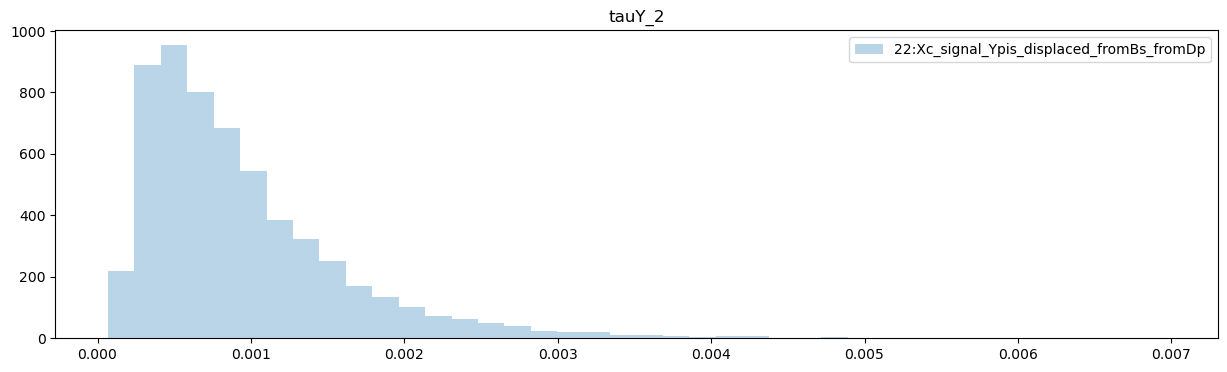

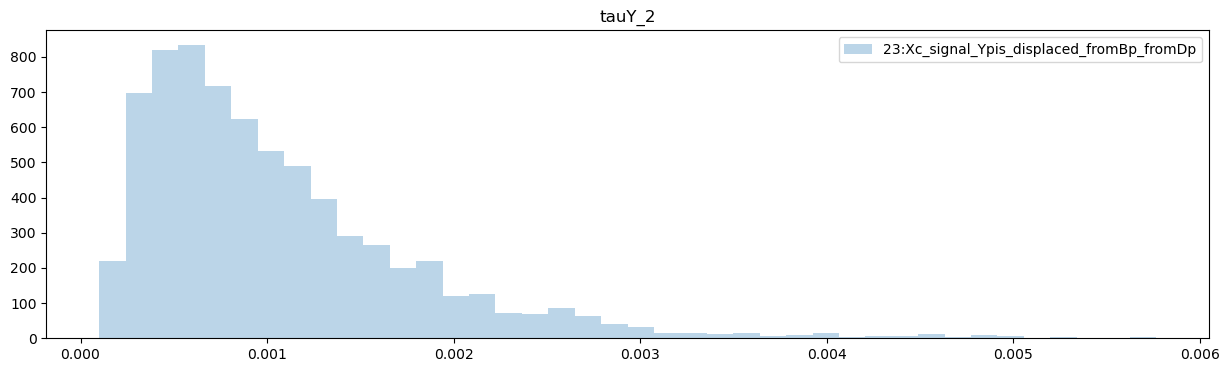

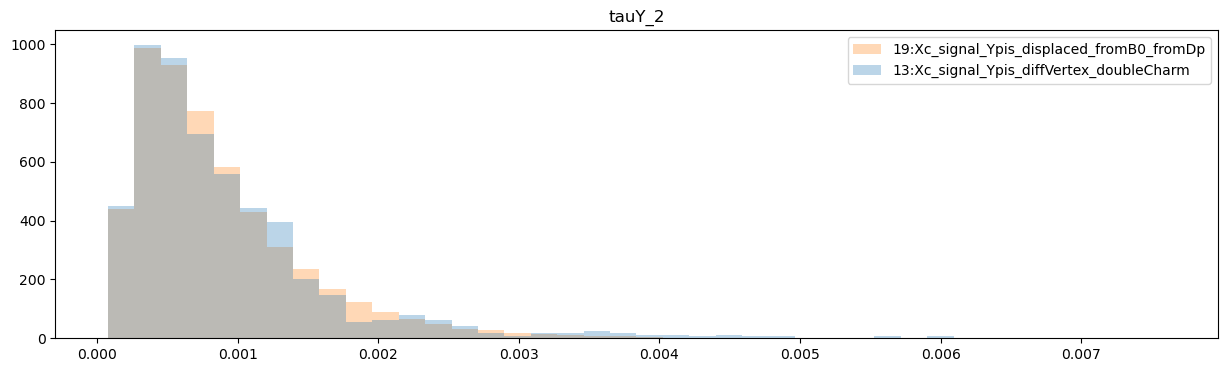

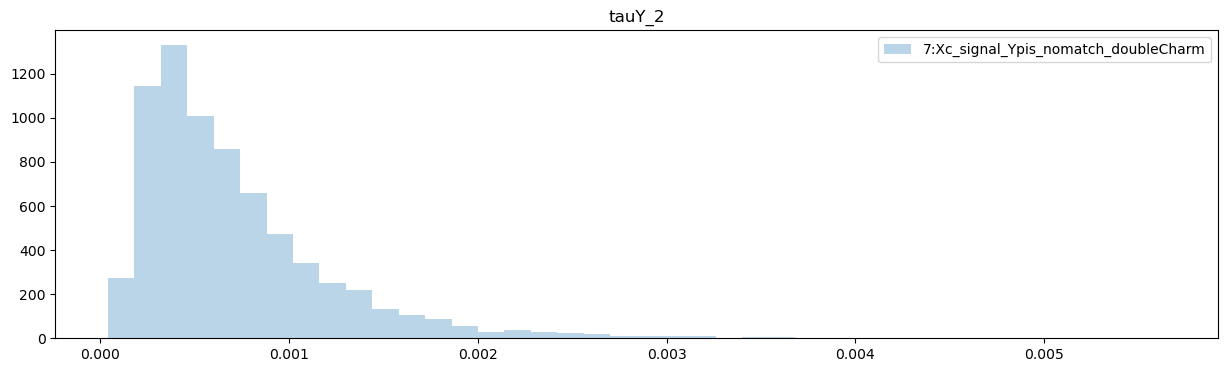

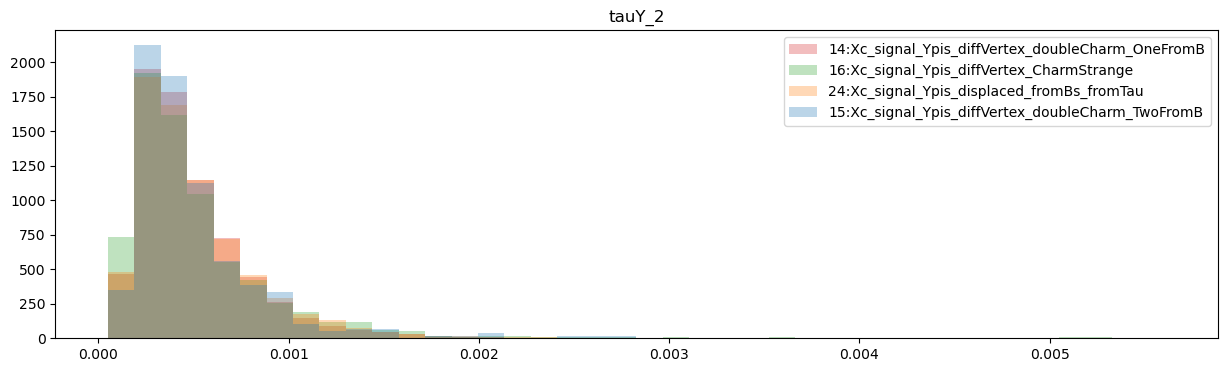

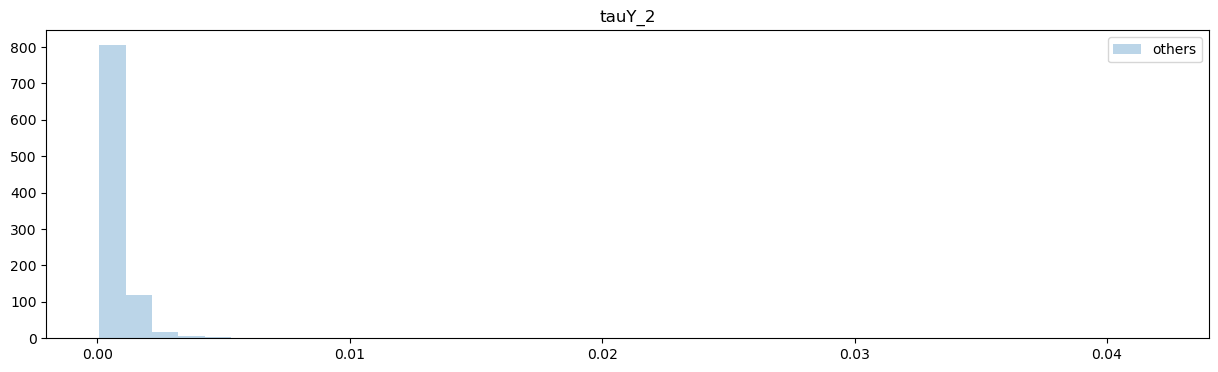

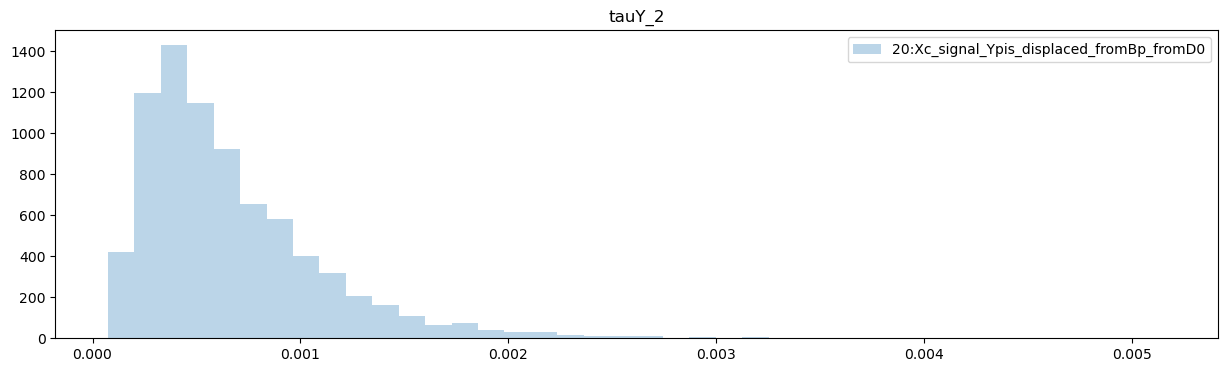

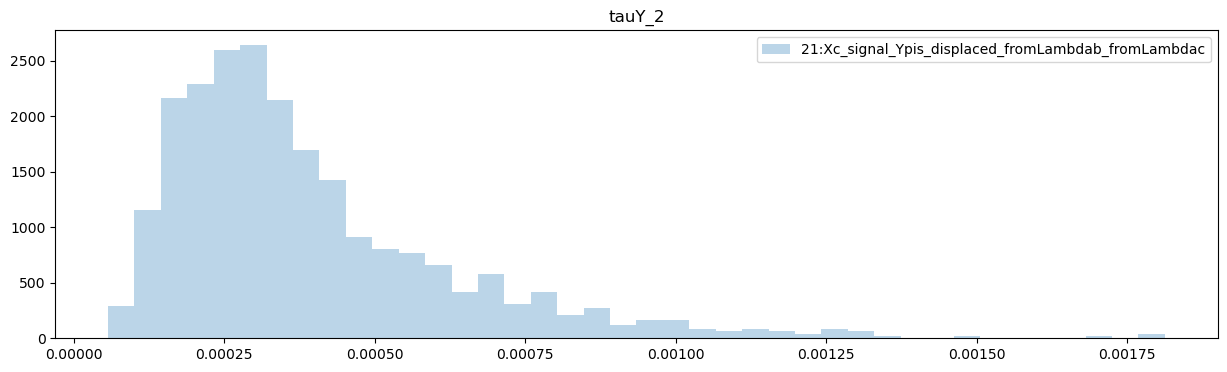

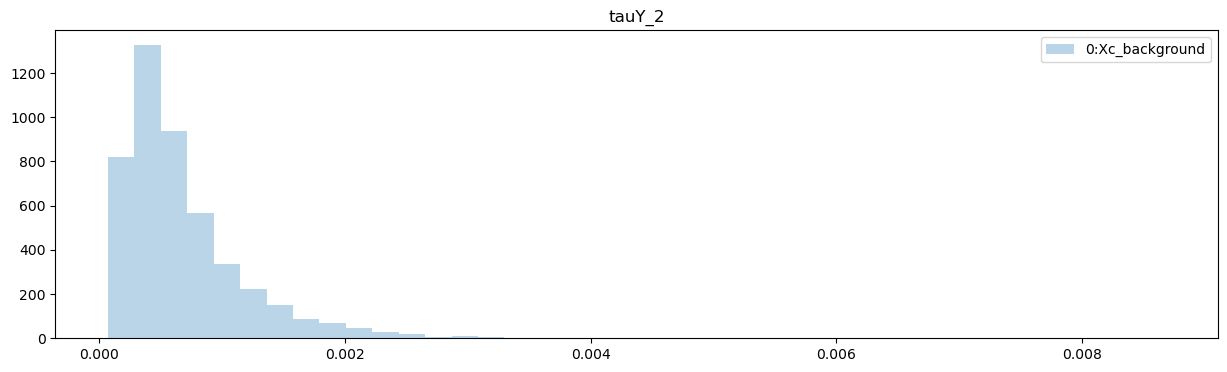

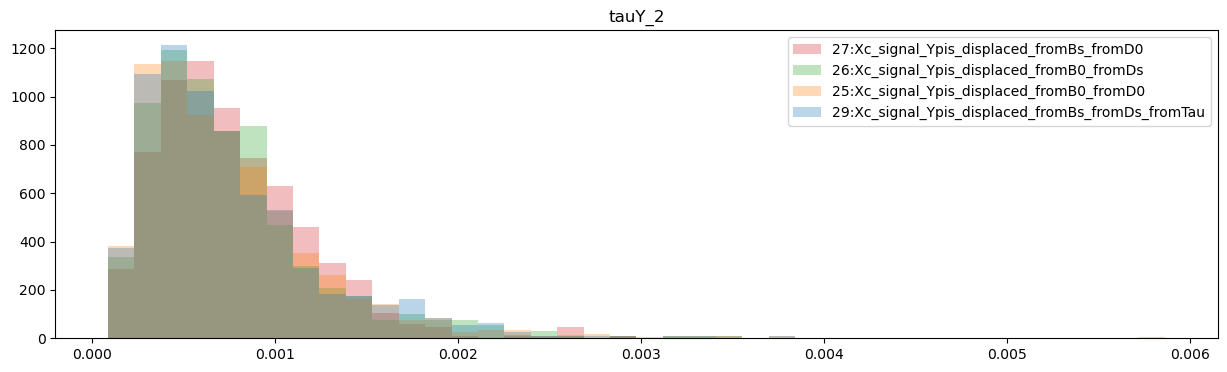

In [32]:
for c in clusters:
    plt.figure()
    plot_templates_categs(c, 'tauY_2')

## Checking bdt_all distributions

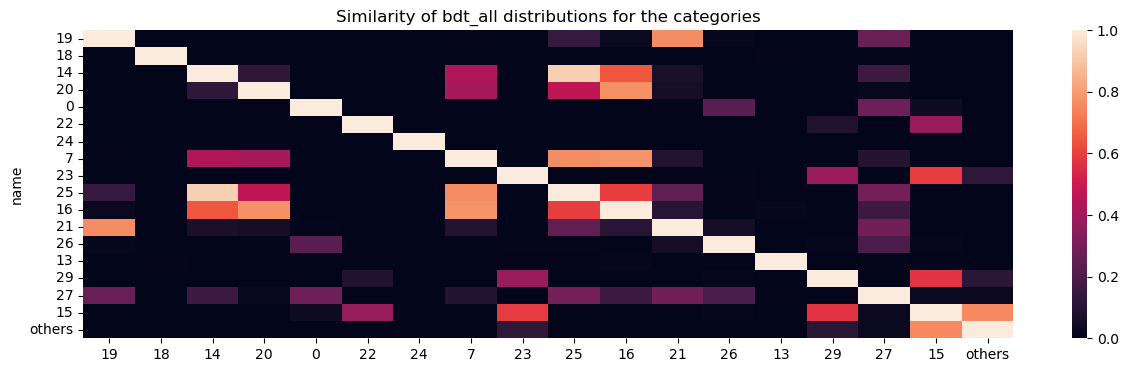

In [33]:
plt.figure()
sn.heatmap(sbdt_all)
plt.title("Similarity of bdt_all distributions for the categories");

In [34]:
from pprint import pprint
clusters = find_and_merge_clusters(sbdt_all, 0.1)
pprint(clusters)

[['18'],
 ['13'],
 ['29', '22', '23', '15', 'others'],
 ['0', '19', '25', '20', '26', '14', '7', '27', '16', '21'],
 ['24']]


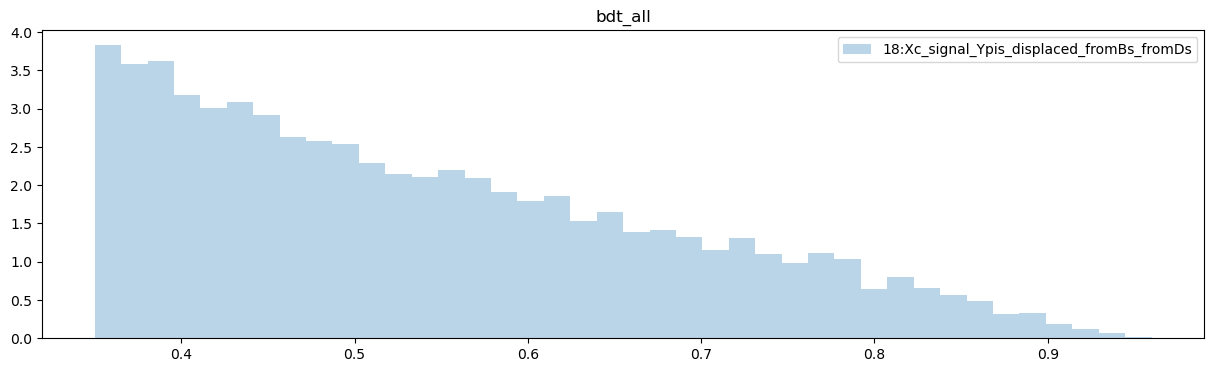

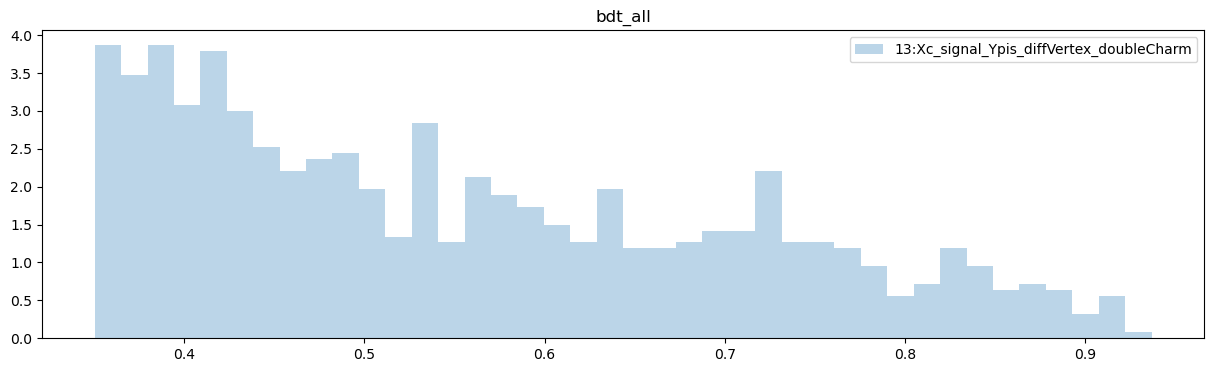

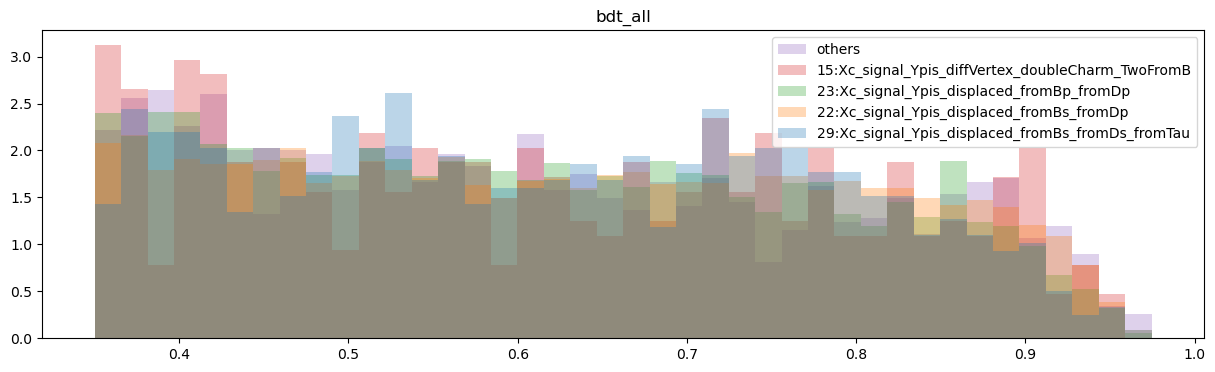

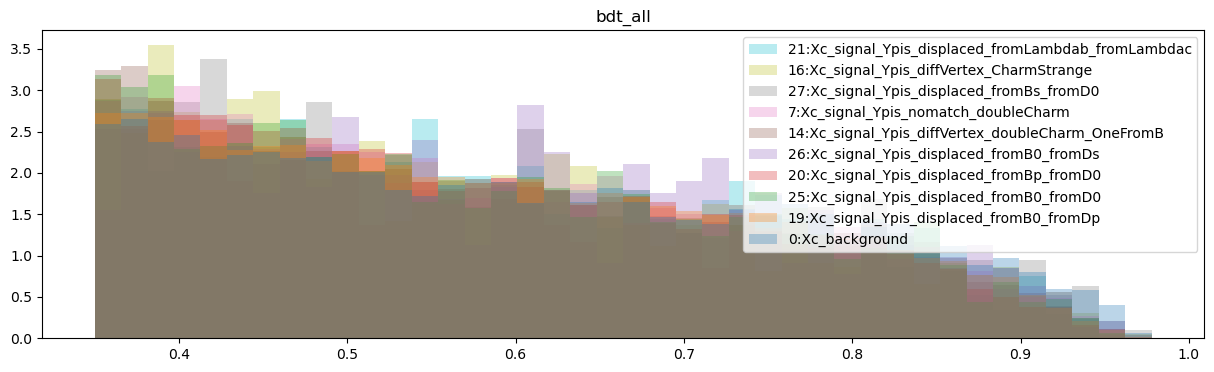

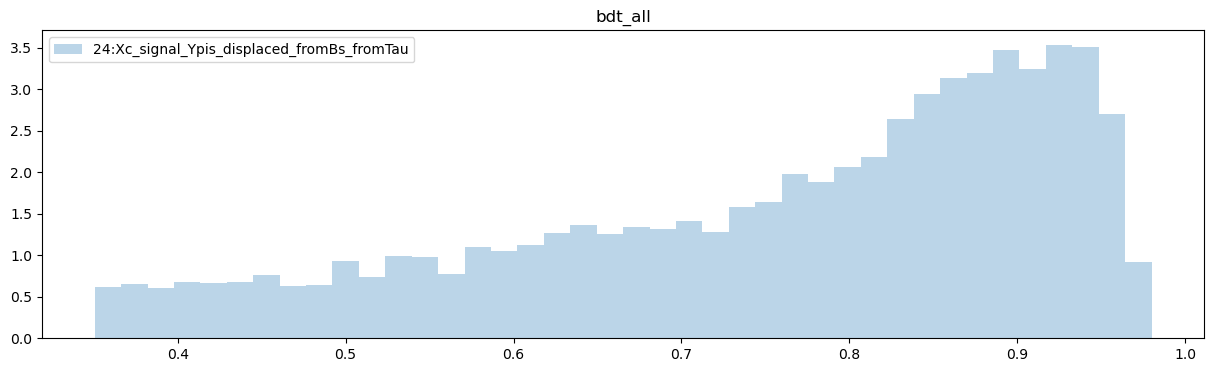

In [35]:
for c in clusters:
    plt.figure()
    plot_templates_categs(c, 'bdt_all')